## Table of Contents
1. [Simulating Data](#Simulating-Data)
2. [Computing LLG and the $R^2$ Lower Bound](#Computing-LLG-and-the-R2-Lower-Bound)
3. [Visualizations](#Visualizations)


## Simulating Data

We generate a simple high-dimensional linear model and split it into an in-sample (train) and out-of-sample (test) set.

In [2]:
import sys
sys.path.append('..')
import numpy as np

seed = 123
rng = np.random.default_rng(seed)

# Dimensions
T_train = 500
T_test = 400
P = 800

sigma_eps = 1.0

# Design matrices
X_train = rng.standard_normal((T_train, P))
X_test = rng.standard_normal((T_test, P))

# True beta 
beta_true = rng.standard_normal(P)
beta_true = beta_true / np.linalg.norm(beta_true)

# Outcomes
y_train = X_train @ beta_true + sigma_eps * rng.standard_normal(T_train)
y_test = X_test @ beta_true + sigma_eps * rng.standard_normal(T_test)

# Ridge grid
z_grid = np.logspace(-4, 2, 100)

## Computing LLG and the $R^2$ Lower Bound

We compute (i) the out-of-sample $R^2$, (ii) the LLG, and (iii) the LLG-adjusted lower bound on $R^2$ over a grid of ridge penalties $z$.

In [3]:
from LLG.llg import LLG_Bounds

confidence_level = 95  # one-sided

model = LLG_Bounds(z_grid=z_grid, confidence_level=confidence_level)
model.fit(X_train, y_train)

# (R2_OOS, asymptotic lower bound, one-side lower CI bound)
r2_oos, r2_lb, lower_bound = model.r2_bounds(X_test, y_test)

# Optional: LLG(z)
llg = model.llg(X_test)


## Visualizations

We plot $R^2_{OOS}(z)$ and the LLG-based asymptotic lower bound, and the 95% confidence bands across the ridge grid.

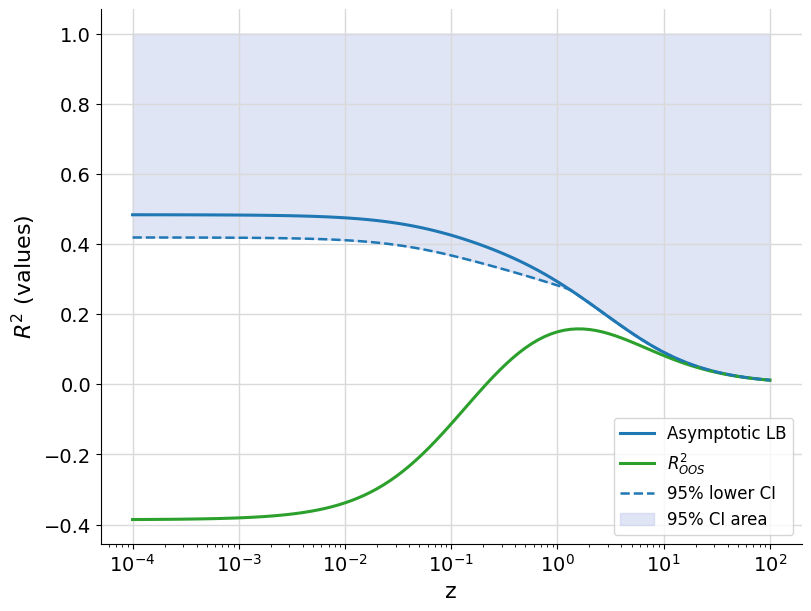

(<Figure size 800x600 with 1 Axes>,
 <Axes: xlabel='z', ylabel='$R^2$ (values)'>)

In [5]:
from utils.plot import plot_r2
plot_r2(z_grid, r2_lb, r2_oos, lower_bound, confidence_level=confidence_level)

